In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px  # interactive figures
import plotly.graph_objects as go
import seaborn as sns


In [2]:
import pandas as pd

df = pd.read_csv("../data_raw/date_24_art_loreal_20%.csv")
df = df[df["ID_ARTICOL"] == 147807]

df.head()


,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_IESIRE_CU_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,STOC_FINAL,RUPTURA_STOC
12,01-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0
19,02-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0
30,03-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.00,770.0,574.75,0.0,0.0,72.25,278,267,0
51,04-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.04,770.0,574.75,0.0,0.0,72.29,267,376,0
64,05-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,10,588.22,700.0,522.50,0.0,0.0,65.72,376,366,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 735 entries, 12 to 9994
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DATA                  735 non-null    object 
 1   ID_ARTICOL            735 non-null    int64  
 2   ARTICOL               735 non-null    object 
 3   CANTITATE             735 non-null    int64  
 4   VAL_IESIRE_FARA_TVA   735 non-null    float64
 5   VAL_IESIRE_CU_TVA     735 non-null    float64
 6   VAL_INTRARE_FARA_TVA  735 non-null    float64
 7   TOTAL_DISCOUNT        735 non-null    float64
 8   RATA_DISCOUNT         704 non-null    float64
 9   ADAOS                 735 non-null    float64
 10  STOC_INITIAL          735 non-null    int64  
 11  STOC_FINAL            735 non-null    int64  
 12  RUPTURA_STOC          735 non-null    int64  
dtypes: float64(6), int64(5), object(2)
memory usage: 80.4+ KB


In [4]:
df.describe()

,ID_ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_IESIRE_CU_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,STOC_FINAL,RUPTURA_STOC
count,735.0,735.000000,735.000000,735.000000,735.000000,735.000000,704.000000,735.000000,735.000000,735.000000,735.0
mean,147807.0,12.378231,646.565102,772.189701,645.127551,110.373088,0.095478,1.437551,341.500680,343.032653,0.0
std,0.0,9.275150,390.917692,467.678411,484.778830,222.537500,0.152401,131.191129,263.160511,266.051928,0.0
min,147807.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-755.080000,38.000000,38.000000,0.0
25%,147807.0,7.000000,417.630000,497.000000,365.750000,0.000000,0.000000,-58.760000,204.000000,204.000000,0.0
50%,147807.0,11.000000,596.620000,710.000000,574.750000,0.000000,0.000000,46.020000,271.000000,271.000000,0.0
75%,147807.0,15.000000,801.810000,958.500000,783.750000,195.250000,0.250000,74.125000,366.000000,366.500000,0.0
max,147807.0,75.000000,3325.640000,4023.750000,3918.750000,1533.600000,0.700000,1029.240000,1577.000000,1577.000000,0.0


### gestionare NULL uri
 cate null uri sunt pe fiecare coloana

ca procent - cate sunt nulle

In [5]:
df.isna().sum()


DATA                     0
ID_ARTICOL               0
ARTICOL                  0
CANTITATE                0
VAL_IESIRE_FARA_TVA      0
VAL_IESIRE_CU_TVA        0
VAL_INTRARE_FARA_TVA     0
TOTAL_DISCOUNT           0
RATA_DISCOUNT           31
ADAOS                    0
STOC_INITIAL             0
STOC_FINAL               0
RUPTURA_STOC             0
dtype: int64

In [6]:
null_report = pd.DataFrame({
    'null_count': df.isna().sum(),
    'null_percent': (df.isna().mean() * 100).round(2)
}).sort_values('null_percent', ascending=False)

null_report


,null_count,null_percent
RATA_DISCOUNT,31,4.22
ID_ARTICOL,0,0.00
ARTICOL,0,0.00
CANTITATE,0,0.00
DATA,0,0.00
VAL_IESIRE_FARA_TVA,0,0.00
VAL_IESIRE_CU_TVA,0,0.00
VAL_INTRARE_FARA_TVA,0,0.00
TOTAL_DISCOUNT,0,0.00
ADAOS,0,0.00


In [7]:
print("raport valori lipsa/ valori bune")

results = []
for c in df.columns:
    # filtram cu conditia ca valorile din coloana c sa fie lipsa si returnam numarul de linii
    missing_cnt = df[ df[c].isna() ].shape[0]
    dict_row ={"nume coloana": c,
                "valori lipsa": str(missing_cnt),
               "procent valori bune": round( 100*(1-missing_cnt/df.shape[0]),2)}
    results.append(dict_row)

display(pd.DataFrame(results))

raport valori lipsa/ valori bune


,nume coloana,valori lipsa,procent valori bune
0,DATA,0,100.00
1,ID_ARTICOL,0,100.00
2,ARTICOL,0,100.00
3,CANTITATE,0,100.00
4,VAL_IESIRE_FARA_TVA,0,100.00
5,VAL_IESIRE_CU_TVA,0,100.00
6,VAL_INTRARE_FARA_TVA,0,100.00
7,TOTAL_DISCOUNT,0,100.00
8,RATA_DISCOUNT,31,95.78
9,ADAOS,0,100.00


Umplerea valorilor nule

In [8]:
df["CANTITATE"] = df["CANTITATE"].fillna(0)


In [9]:
df.isna().sum()

DATA                     0
ID_ARTICOL               0
ARTICOL                  0
CANTITATE                0
VAL_IESIRE_FARA_TVA      0
VAL_IESIRE_CU_TVA        0
VAL_INTRARE_FARA_TVA     0
TOTAL_DISCOUNT           0
RATA_DISCOUNT           31
ADAOS                    0
STOC_INITIAL             0
STOC_FINAL               0
RUPTURA_STOC             0
dtype: int64

In [10]:
mask = df["CANTITATE"] == 0
cols_val = ["VAL_IESIRE_FARA_TVA", "VAL_IESIRE_CU_TVA"]

df.loc[mask, cols_val] = df.loc[mask, cols_val].fillna(0)

#  umplem cu 0 coloanele de valori doar daca si cantitatea este 0 


In [11]:
df.isna().sum()

DATA                     0
ID_ARTICOL               0
ARTICOL                  0
CANTITATE                0
VAL_IESIRE_FARA_TVA      0
VAL_IESIRE_CU_TVA        0
VAL_INTRARE_FARA_TVA     0
TOTAL_DISCOUNT           0
RATA_DISCOUNT           31
ADAOS                    0
STOC_INITIAL             0
STOC_FINAL               0
RUPTURA_STOC             0
dtype: int64

In [12]:
df[df["TOTAL_DISCOUNT"].isna()][
    ["CANTITATE", "RATA_DISCOUNT", "VAL_IESIRE_CU_TVA"]
]


,CANTITATE,RATA_DISCOUNT,VAL_IESIRE_CU_TVA


In [13]:
df["TOTAL_DISCOUNT"] = df["TOTAL_DISCOUNT"].fillna(0)


In [14]:
df.isna().sum()

DATA                     0
ID_ARTICOL               0
ARTICOL                  0
CANTITATE                0
VAL_IESIRE_FARA_TVA      0
VAL_IESIRE_CU_TVA        0
VAL_INTRARE_FARA_TVA     0
TOTAL_DISCOUNT           0
RATA_DISCOUNT           31
ADAOS                    0
STOC_INITIAL             0
STOC_FINAL               0
RUPTURA_STOC             0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 735 entries, 12 to 9994
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DATA                  735 non-null    object 
 1   ID_ARTICOL            735 non-null    int64  
 2   ARTICOL               735 non-null    object 
 3   CANTITATE             735 non-null    int64  
 4   VAL_IESIRE_FARA_TVA   735 non-null    float64
 5   VAL_IESIRE_CU_TVA     735 non-null    float64
 6   VAL_INTRARE_FARA_TVA  735 non-null    float64
 7   TOTAL_DISCOUNT        735 non-null    float64
 8   RATA_DISCOUNT         704 non-null    float64
 9   ADAOS                 735 non-null    float64
 10  STOC_INITIAL          735 non-null    int64  
 11  STOC_FINAL            735 non-null    int64  
 12  RUPTURA_STOC          735 non-null    int64  
dtypes: float64(6), int64(5), object(2)
memory usage: 80.4+ KB


In [16]:
#  RUPTURA STOC - 1 - stoc_final = 0 

In [17]:
df.shape

(735, 13)

In [18]:
df.describe()

,ID_ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_IESIRE_CU_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,STOC_FINAL,RUPTURA_STOC
count,735.0,735.000000,735.000000,735.000000,735.000000,735.000000,704.000000,735.000000,735.000000,735.000000,735.0
mean,147807.0,12.378231,646.565102,772.189701,645.127551,110.373088,0.095478,1.437551,341.500680,343.032653,0.0
std,0.0,9.275150,390.917692,467.678411,484.778830,222.537500,0.152401,131.191129,263.160511,266.051928,0.0
min,147807.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-755.080000,38.000000,38.000000,0.0
25%,147807.0,7.000000,417.630000,497.000000,365.750000,0.000000,0.000000,-58.760000,204.000000,204.000000,0.0
50%,147807.0,11.000000,596.620000,710.000000,574.750000,0.000000,0.000000,46.020000,271.000000,271.000000,0.0
75%,147807.0,15.000000,801.810000,958.500000,783.750000,195.250000,0.250000,74.125000,366.000000,366.500000,0.0
max,147807.0,75.000000,3325.640000,4023.750000,3918.750000,1533.600000,0.700000,1029.240000,1577.000000,1577.000000,0.0


standard deviation is a way to measure how "spread out" or "different" the values in a group are from the average.

If the standard deviation is small, it means most values are close to the average (not much variation).
If the standard deviation is large, it means the values are spread out and vary a lot from the average.

Conversie coloana data din object in datetime

In [19]:
df['DATA'] = pd.to_datetime(df['DATA'], errors="coerce")

C:\Users\Mara\AppData\Local\Temp\ipykernel_29344\2340964975.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATA'] = pd.to_datetime(df['DATA'], errors="coerce")


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 735 entries, 12 to 9994
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   DATA                  735 non-null    datetime64[ns]
 1   ID_ARTICOL            735 non-null    int64         
 2   ARTICOL               735 non-null    object        
 3   CANTITATE             735 non-null    int64         
 4   VAL_IESIRE_FARA_TVA   735 non-null    float64       
 5   VAL_IESIRE_CU_TVA     735 non-null    float64       
 6   VAL_INTRARE_FARA_TVA  735 non-null    float64       
 7   TOTAL_DISCOUNT        735 non-null    float64       
 8   RATA_DISCOUNT         704 non-null    float64       
 9   ADAOS                 735 non-null    float64       
 10  STOC_INITIAL          735 non-null    int64         
 11  STOC_FINAL            735 non-null    int64         
 12  RUPTURA_STOC          735 non-null    int64         
dtypes: datetime64[ns](1), f

In [21]:
# Sortare logică pentru time series
df = df.sort_values(by=["DATA"]).reset_index(drop=True)

In [22]:
df

,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_IESIRE_CU_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,STOC_FINAL,RUPTURA_STOC
0,2024-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0
1,2024-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0
2,2024-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.00,770.0,574.75,0.0,0.0,72.25,278,267,0
3,2024-01-04,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.04,770.0,574.75,0.0,0.0,72.29,267,376,0
4,2024-01-05,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,10,588.22,700.0,522.50,0.0,0.0,65.72,376,366,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,2025-12-31,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,7,419.44,507.5,365.75,0.0,0.0,53.69,1429,1422,0
731,2026-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,1422,1422,0
732,2026-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,1422,1422,0
733,2026-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,13,778.96,942.5,679.25,0.0,0.0,99.71,1422,1409,0


In [23]:
# reguli de calitate
checks = {}

# 1) vânzare > 0 dar valoare = 0 (suspect)
checks["qty_pos_val_zero"] = df[(df["CANTITATE"] > 0) & (df["VAL_IESIRE_CU_TVA"] == 0)]

# 2) valoare > 0 dar cantitate = 0 (suspect)
checks["val_pos_qty_zero"] = df[(df["VAL_IESIRE_CU_TVA"] > 0) & (df["CANTITATE"] == 0)]

# 3) stoc final negativ (dacă există în dataset)
if "STOC_FINAL" in df.columns:
    checks["stoc_final_negativ"] = df[df["STOC_FINAL"] < 0]

# 4) discount > 0 dar rata_discount = 0 (suspect)
if "TOTAL_DISCOUNT" in df.columns and "RATA_DISCOUNT" in df.columns:
    checks["disc_pos_rata_zero"] = df[(df["TOTAL_DISCOUNT"] > 0) & (df["RATA_DISCOUNT"] == 0)]

# 5) 
checks["stockout_start"] = df[(df["STOC_INITIAL"] == 0) & (df["CANTITATE"] == 0)]
checks["no_sales_but_in_stock"] = df[(df["STOC_INITIAL"] > 0) & (df["CANTITATE"] == 0)]


{k: v.shape[0] for k, v in checks.items()}

{'qty_pos_val_zero': 0,
 'val_pos_qty_zero': 0,
 'stoc_final_negativ': 0,
 'disc_pos_rata_zero': 0,
 'stockout_start': 0,
 'no_sales_but_in_stock': 16}

In [24]:
cols = ["CANTITATE", "STOC_INITIAL", "STOC_FINAL", "VAL_IESIRE_FARA_TVA"]

(df[cols] < 0).sum()


CANTITATE              0
STOC_INITIAL           0
STOC_FINAL             0
VAL_IESIRE_FARA_TVA    0
dtype: int64

In [25]:

num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

In [26]:
num_cols

['ID_ARTICOL',
 'CANTITATE',
 'VAL_IESIRE_FARA_TVA',
 'VAL_IESIRE_CU_TVA',
 'VAL_INTRARE_FARA_TVA',
 'TOTAL_DISCOUNT',
 'RATA_DISCOUNT',
 'ADAOS',
 'STOC_INITIAL',
 'STOC_FINAL',
 'RUPTURA_STOC']

In [27]:
# df = df.set_index('DATA') 

In [28]:
# df

## EDA 

### Overview, trends, outliers

In [29]:
# sns.pairplot(df) # Visualize relationships between features

# plt.show()

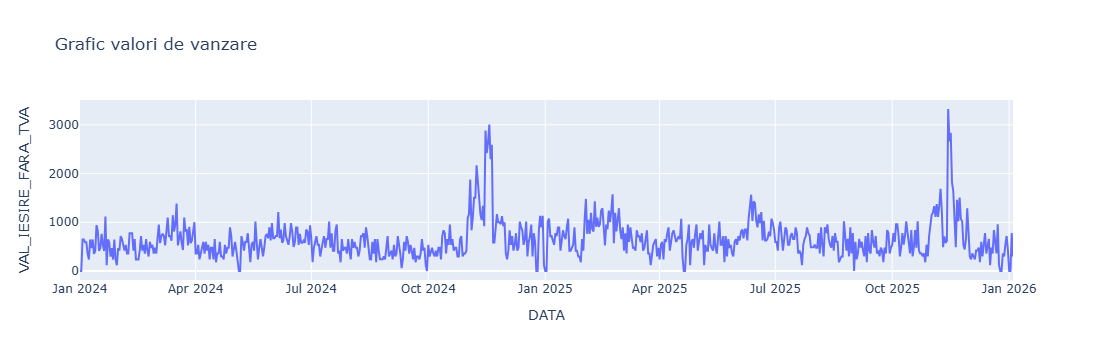

In [30]:
fig = px.line(df, x='DATA', y="VAL_IESIRE_FARA_TVA", title = 'Grafic valori de vanzare')
fig.show()

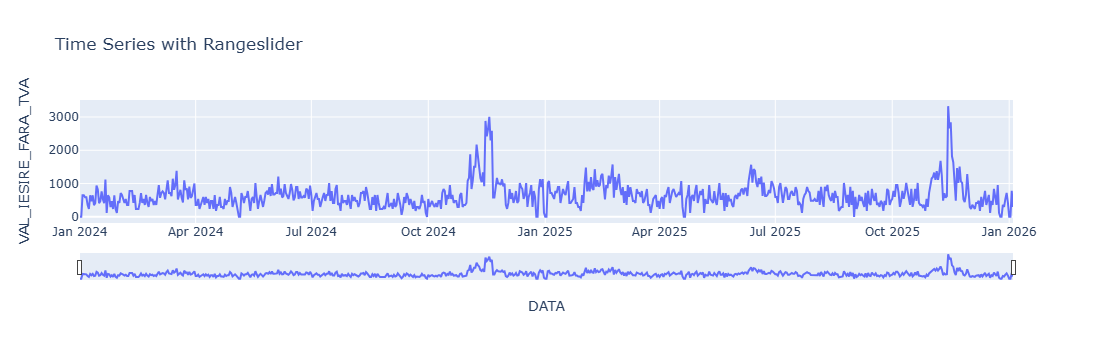

In [31]:
fig = px.line(df, x='DATA', y='VAL_IESIRE_FARA_TVA', title='Time Series with Rangeslider')

fig.update_xaxes(rangeslider_visible=True)
fig.show()

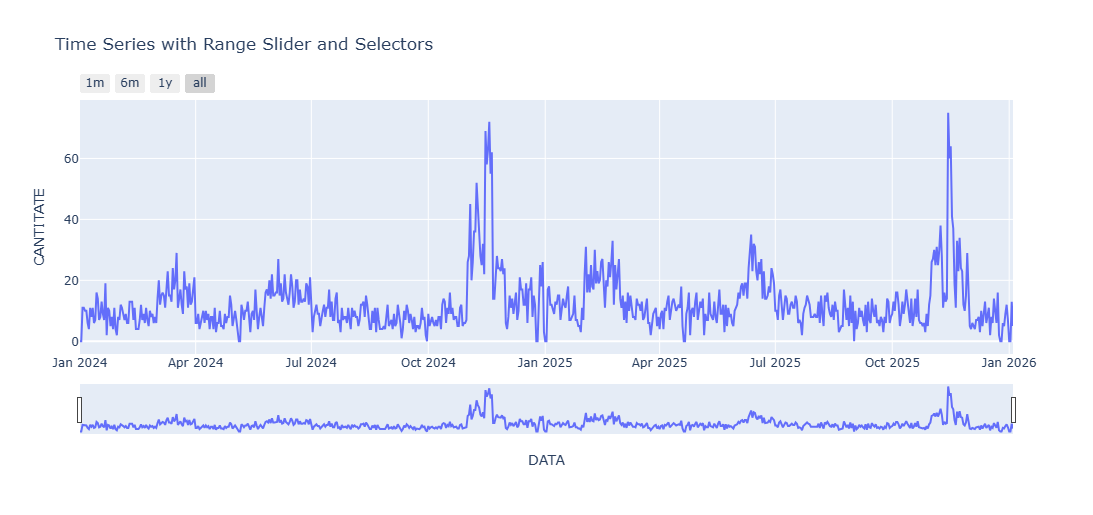

In [32]:
fig = px.line(df, x='DATA', y='CANTITATE', title='Time Series with Range Slider and Selectors')

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            # dict(count=1, label="YTD", step="year", stepmode="todate"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)

fig.update_layout(width=1100, height=500)
fig.show()

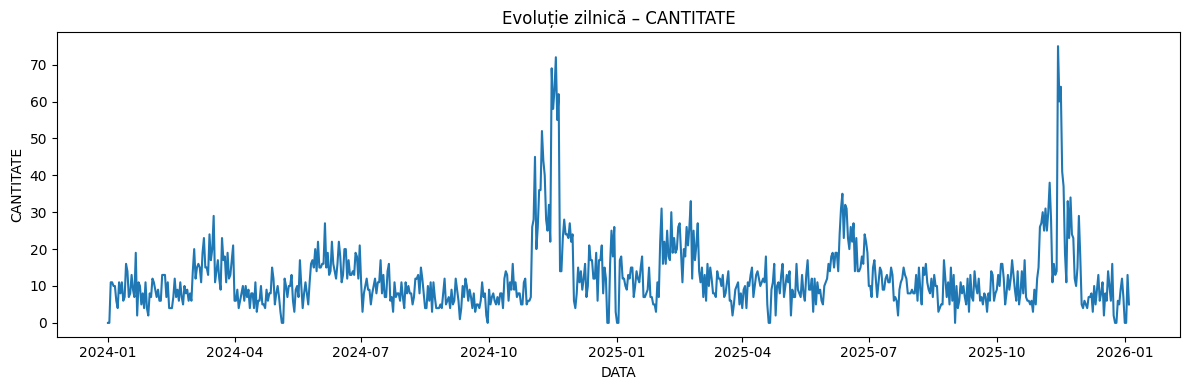

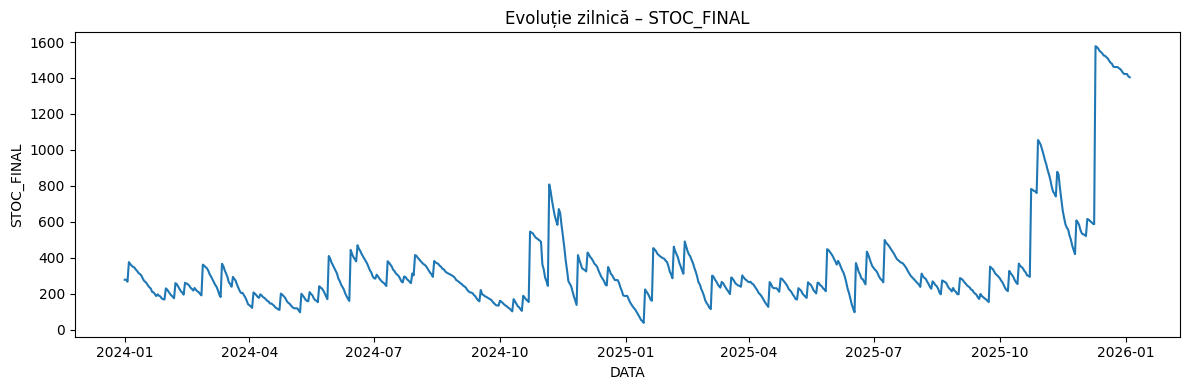

In [33]:
plt.figure(figsize=(12,4))
plt.plot(df["DATA"], df["CANTITATE"])
plt.title("Evoluție zilnică – CANTITATE")
plt.xlabel("DATA"); plt.ylabel("CANTITATE")
plt.tight_layout()
plt.show()


plt.figure(figsize=(12,4))
plt.plot(df["DATA"], df["STOC_FINAL"])
plt.title("Evoluție zilnică – STOC_FINAL")
plt.xlabel("DATA"); plt.ylabel("STOC_FINAL")
plt.tight_layout()
plt.show()


### Analiza anomaliior / Outliers ( Outlier detection ) 

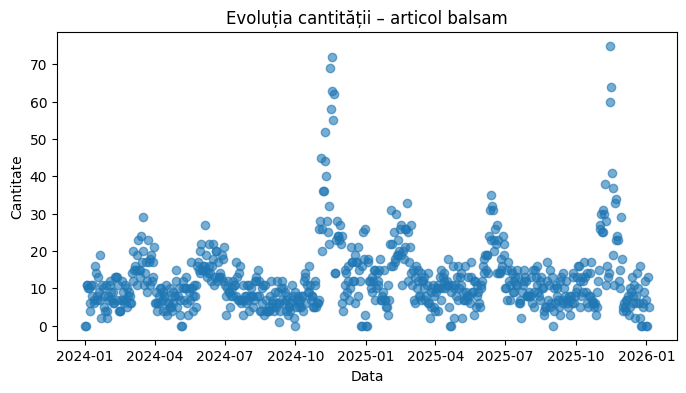

In [34]:
plt.figure(figsize=(8,4))
plt.scatter(df["DATA"], df["CANTITATE"], alpha=0.6)
plt.title(f"Evoluția cantității – articol balsam")
plt.xlabel("Data")
plt.ylabel("Cantitate")
plt.show()


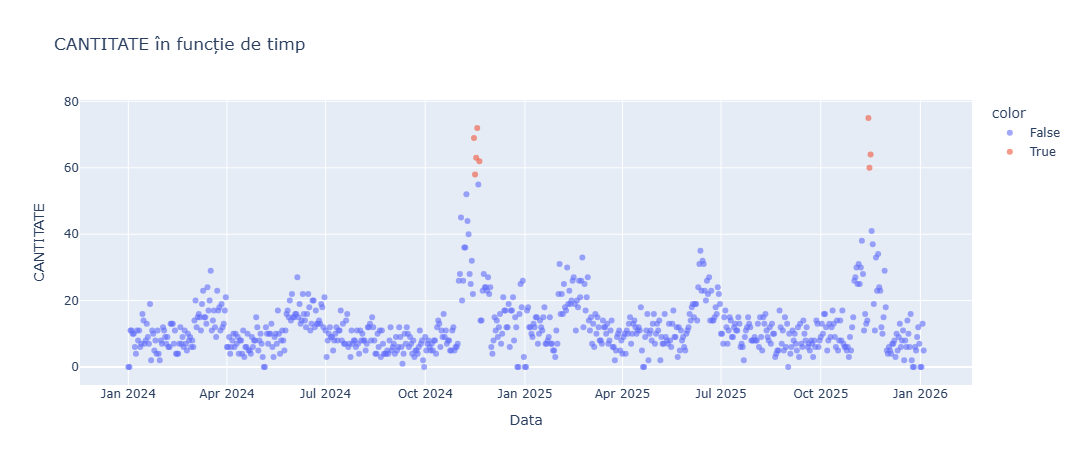

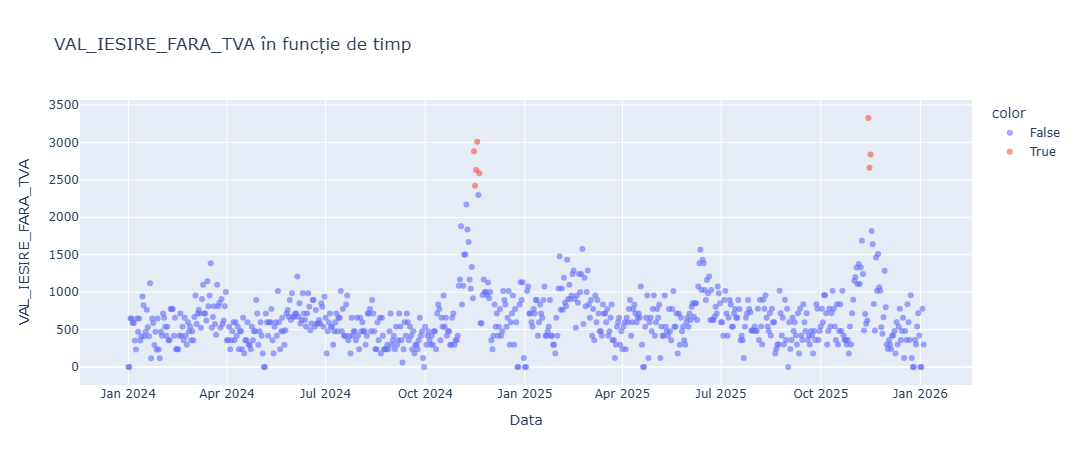

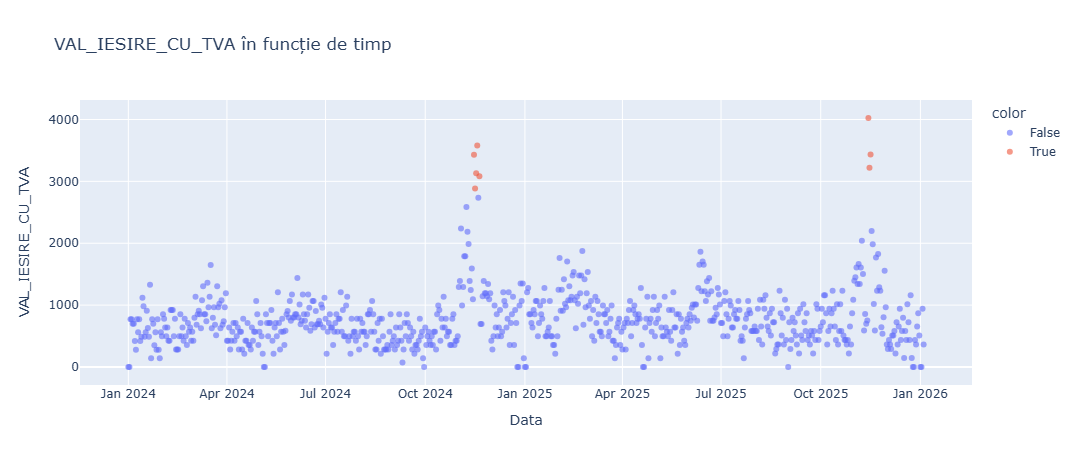

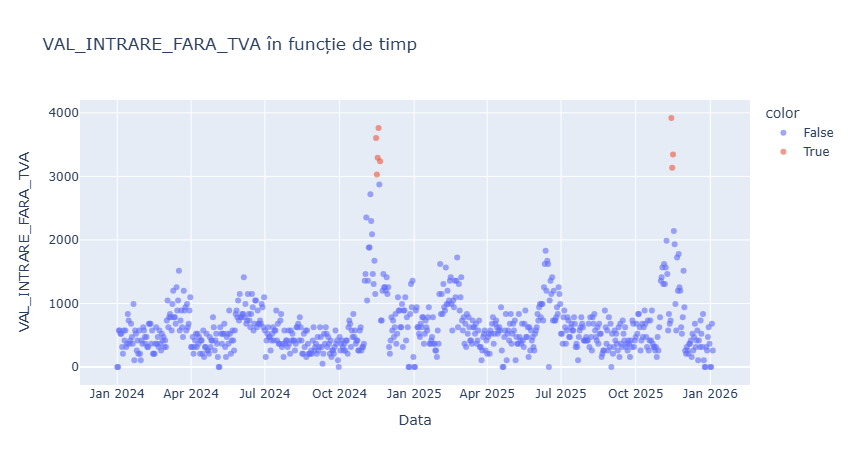

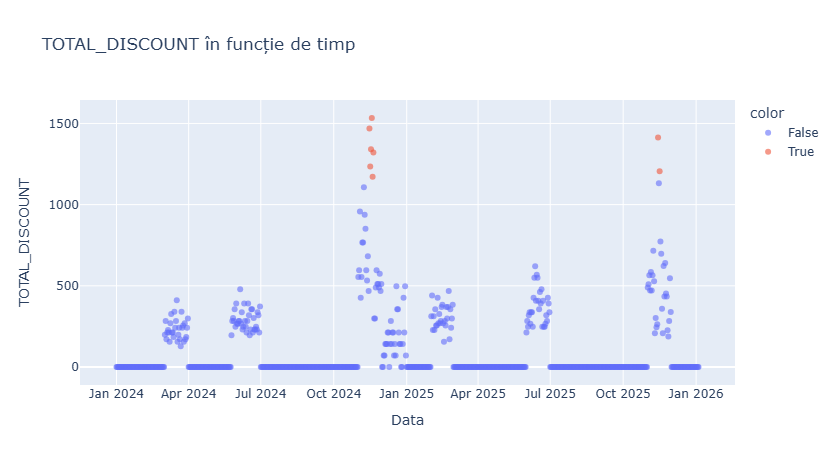

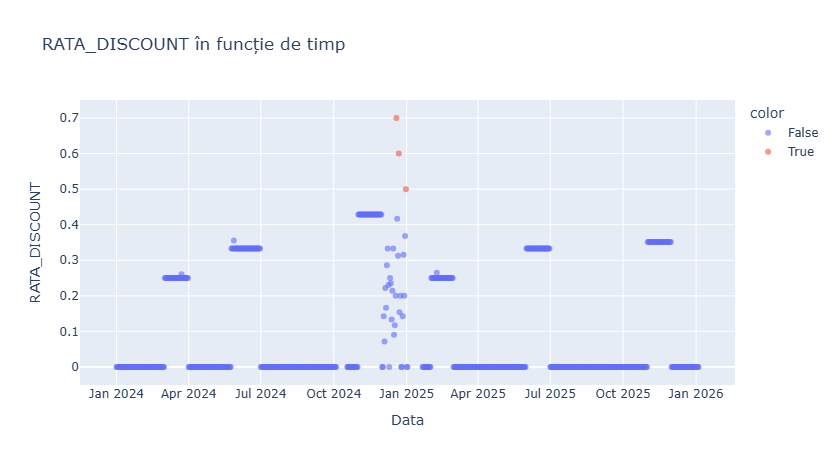

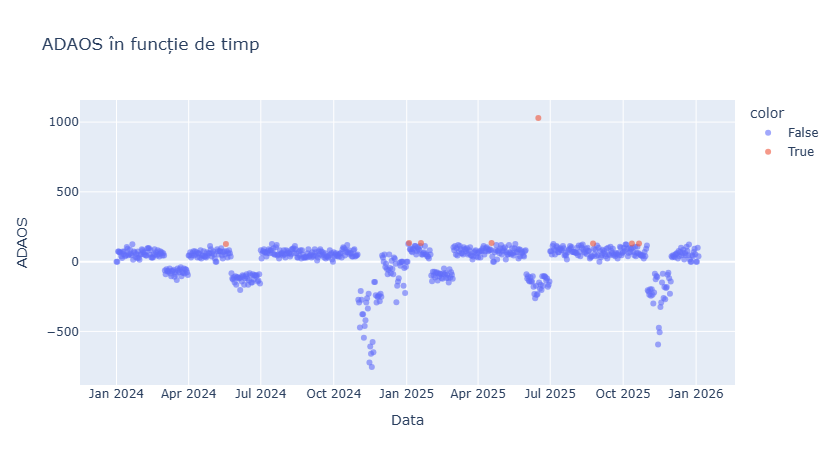

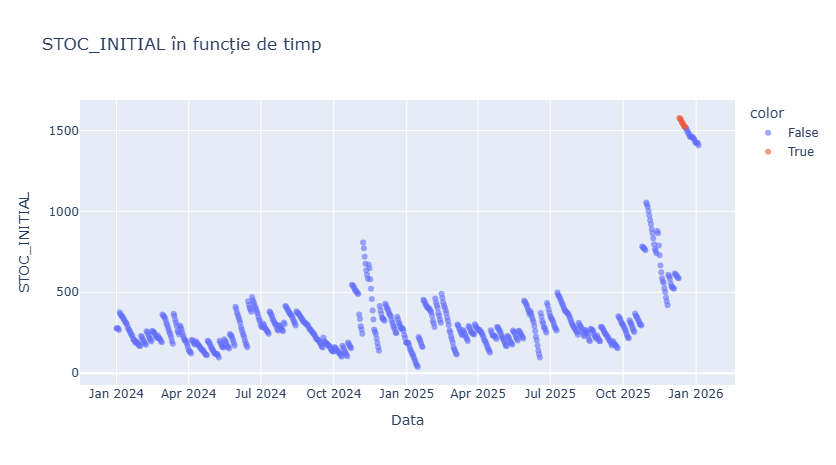

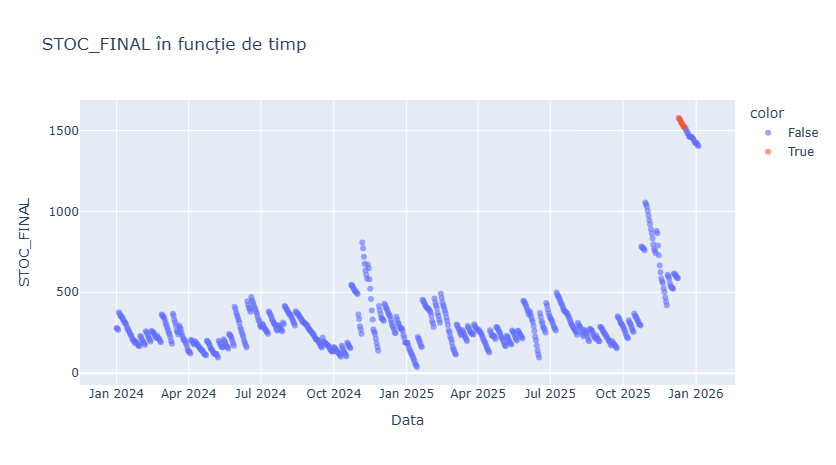

In [35]:
num_cols = [
    c for c in df.select_dtypes(include="number").columns
    if c not in {"RUPTURA_STOC", "ID_ARTICOL"}
]


for col in num_cols:
    fig = px.scatter(
        df,
        x="DATA",
        y=col,
        color=df[col] > df[col].quantile(0.99),
        title=f"{col} în funcție de timp",
        opacity=0.6
    )

    fig.update_layout(
        width=1100,
        height=450,
        xaxis_title="Data",
        yaxis_title=col
    )

    fig.show()


In [36]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

exclude_cols = {"RUPTURA_STOC", "ID_ARTICOL"}

num_cols = [
    c for c in df.select_dtypes(include="number").columns
    if c not in exclude_cols
]

df["DATA"] = pd.to_datetime(df["DATA"])

divs = []
for col in num_cols:
    fig = px.scatter(df, x="DATA", y=col, title=col, opacity=0.6)
    fig.update_layout(width=700, height=350, margin=dict(l=30, r=10, t=50, b=30))
    divs.append(pio.to_html(fig, full_html=False, include_plotlyjs="cdn"))

html = f"""
<div style="height:800px; overflow:auto; border:1px solid #ddd; padding:10px;">
  <div style="display:grid; grid-template-columns: repeat(2, 1fr); gap:12px;">
    {''.join(f'<div style="background:#fff; border:1px solid #eee; padding:6px;">{d}</div>' for d in divs)}
  </div>
</div>
"""

from IPython.display import HTML
HTML(html)

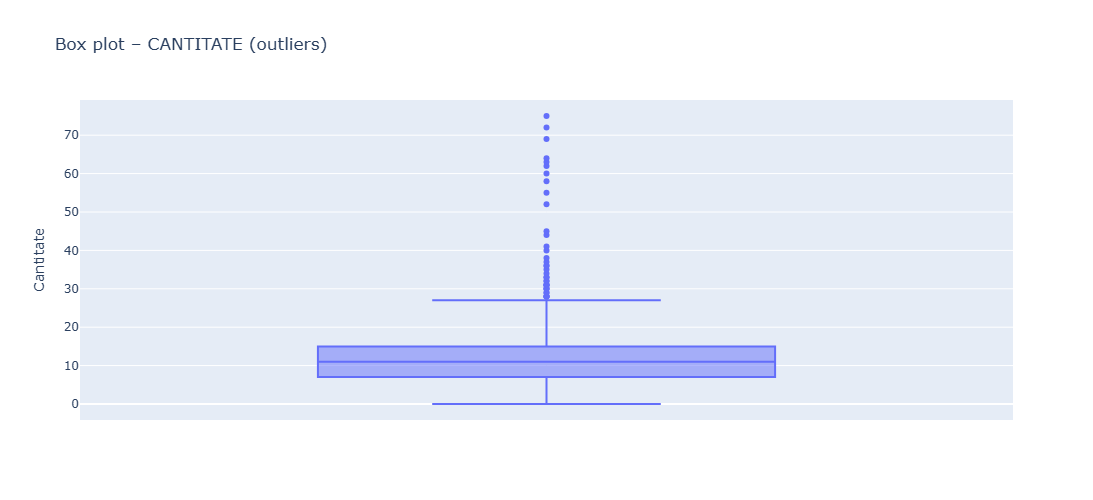

In [37]:
fig = px.box(
    df,
    y="CANTITATE",
    points="outliers",  # afișează DOAR outliers
    title="Box plot – CANTITATE (outliers)"
)

fig.update_layout(
    width=600,
    height=500,
    yaxis_title="Cantitate"
)

fig.show()

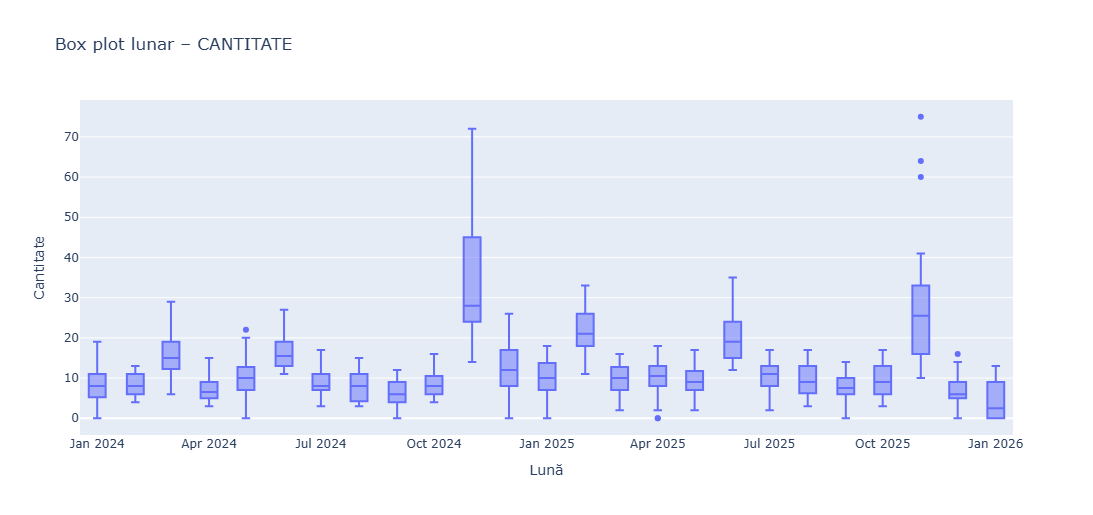

In [38]:
df["LUNA"] = df["DATA"].dt.to_period("M").astype(str)

fig = px.box(
    df,
    x="LUNA",
    y="CANTITATE",
    points="outliers",
    title="Box plot lunar – CANTITATE "
)

fig.update_layout(
    width=1100,
    height=500,
    xaxis_title="Lună",
    yaxis_title="Cantitate"
)

fig.show()


In [39]:
# df["Year"] = df.DATA.dt.year
# df["Quarter"] = df.DATA.dt.quarter
# df["Month"] = df.DATA.dt.month
# df["Weekday"] = df.DATA.dt.weekday
# df["Day"] = df.DATA.dt.day
# df["Dayofyear"] = df.DATA.dt.dayofyear
# df["Date"] = pd.to_datetime(df[['Year', 'Month', 'Day']])

# df

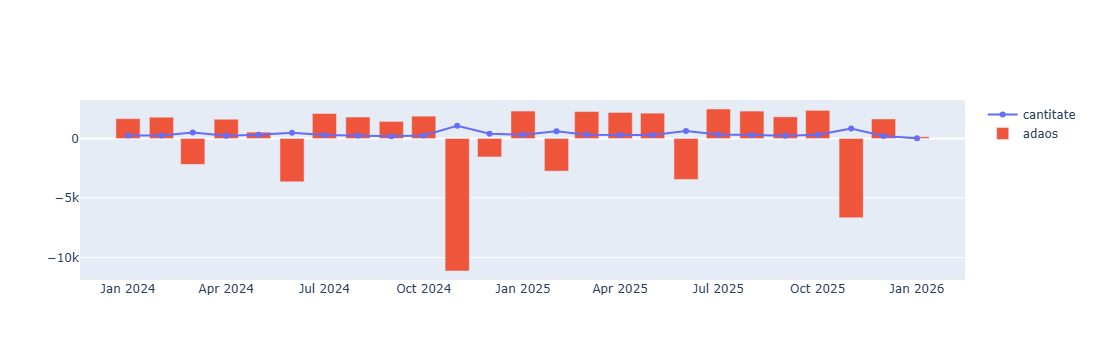

In [40]:
import plotly.graph_objects as go

df_plot = (
    df.groupby("LUNA", as_index=False)
      .agg({"CANTITATE":"sum", "VAL_IESIRE_FARA_TVA":"sum", "ADAOS":"sum"})
      .sort_values("LUNA")
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_plot["LUNA"],
        y=df_plot["CANTITATE"],
        mode="lines+markers",
        name = "cantitate"
    ))

# fig.add_trace(
#     go.Scatter(
#         x=df_plot["LUNA"],
#         y=df_plot["VAL_IESIRE_FARA_TVA"],
#         mode="lines+markers",
#         name = "valoare iesire"
#     ))

fig.add_trace(
    go.Bar(
        x=df_plot["LUNA"],
        y=df_plot["ADAOS"],
        name = "adaos"
    ))

# fig.update_layout(
#     title="Evoluție lunară: Cantitate (bare) vs Valoare ieșire & Adaos (linii)")

fig.show()

In [41]:
df

,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_IESIRE_CU_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,STOC_FINAL,RUPTURA_STOC,LUNA
0,2024-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0,2024-01
1,2024-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0,2024-01
2,2024-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.00,770.0,574.75,0.0,0.0,72.25,278,267,0,2024-01
3,2024-01-04,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.04,770.0,574.75,0.0,0.0,72.29,267,376,0,2024-01
4,2024-01-05,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,10,588.22,700.0,522.50,0.0,0.0,65.72,376,366,0,2024-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,2025-12-31,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,7,419.44,507.5,365.75,0.0,0.0,53.69,1429,1422,0,2025-12
731,2026-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,1422,1422,0,2026-01
732,2026-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,1422,1422,0,2026-01
733,2026-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,13,778.96,942.5,679.25,0.0,0.0,99.71,1422,1409,0,2026-01


In [42]:
num_corr = df[num_cols].corr(method = 'pearson')
num_corr

,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_IESIRE_CU_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,STOC_FINAL
CANTITATE,1.000000,0.981449,0.981118,0.995818,0.915775,0.687994,-0.755280,0.141846,0.109224
VAL_IESIRE_FARA_TVA,0.981449,1.000000,0.999906,0.977834,0.821862,0.576363,-0.633546,0.116422,0.083474
VAL_IESIRE_CU_TVA,0.981118,0.999906,1.000000,0.977542,0.821285,0.574588,-0.632744,0.121486,0.088473
VAL_INTRARE_FARA_TVA,0.995818,0.977834,0.977542,1.000000,0.910967,0.682350,-0.781502,0.144387,0.112059
TOTAL_DISCOUNT,0.915775,0.821862,0.821285,0.910967,1.000000,0.841084,-0.917265,0.182777,0.154695
RATA_DISCOUNT,0.687994,0.576363,0.574588,0.682350,0.841084,1.000000,-0.813133,0.110939,0.093702
ADAOS,-0.755280,-0.633546,-0.632744,-0.781502,-0.917265,-0.813133,1.000000,-0.186633,-0.165351
STOC_INITIAL,0.141846,0.116422,0.121486,0.144387,0.182777,0.110939,-0.186633,1.000000,0.970477
STOC_FINAL,0.109224,0.083474,0.088473,0.112059,0.154695,0.093702,-0.165351,0.970477,1.000000


<Axes: >

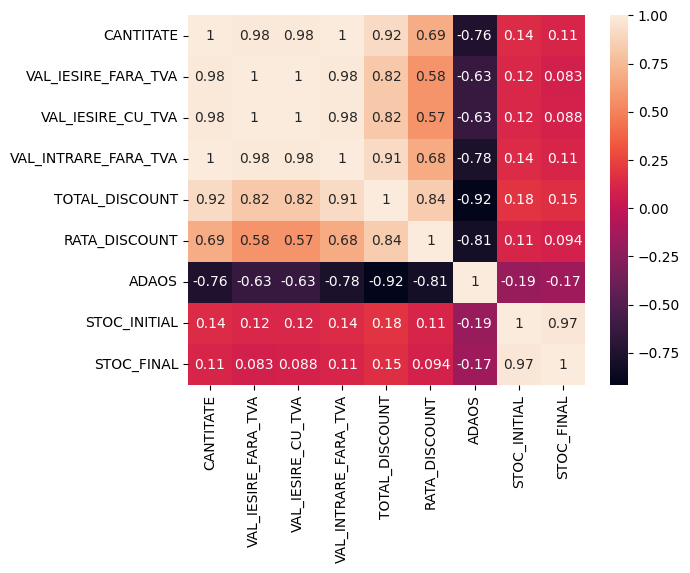

In [43]:
sns.heatmap(num_corr, annot = True)

#### Heatmap - Corelatie Pearson 
##### valorile apropiate de 1 (sau -1) indică variabile puternic corelate.

##### Interpretari :
CANTITATE ↔ VAL_IESIRE (≈ 0.53)
- logic economic: vânzări mai mari → valoare mai mare

TOTAL_DISCOUNT ↔ RATA_DISCOUNT (≈ 0.92)
- redundanță aproape totală (aceeași informație, exprimată diferit)

STOC_INITIAL ↔ STOC_FINAL (≈ 0.95)
- confirmă coerența procesului de gestiune

ADAOS ↔ DISCOUNT (≈ −0.6)
- discounturile erodează adaosul → insight managerial important

RUPTURA_STOC ↔ STOC_FINAL (≈ −0.17)
- când stocul final e mic, riscul de ruptură crește

Pentru evitarea redundanței informaționale, variabilele puternic corelate vor fi filtrate.  ( gen val iesire cu fara tva, total discount - rata discount )

In [44]:
df_feat = df.drop(columns=[ "STOC_FINAL", "RUPTURA_STOC", "VAL_IESIRE_CU_TVA", "RATA_DISCOUNT"])

df_feat


,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,ADAOS,STOC_INITIAL,LUNA
0,2024-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,278,2024-01
1,2024-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,278,2024-01
2,2024-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.00,574.75,0.0,72.25,278,2024-01
3,2024-01-04,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.04,574.75,0.0,72.29,267,2024-01
4,2024-01-05,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,10,588.22,522.50,0.0,65.72,376,2024-01
...,...,...,...,...,...,...,...,...,...,...
730,2025-12-31,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,7,419.44,365.75,0.0,53.69,1429,2025-12
731,2026-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,1422,2026-01
732,2026-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,1422,2026-01
733,2026-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,13,778.96,679.25,0.0,99.71,1422,2026-01


In [45]:

df_feat["DOW"] = df_feat["DATA"].dt.dayofweek          # 0..6
df_feat["ESTE_WEEKEND"] = (df_feat["DOW"] >= 5).astype(int)

# dacă ai deja LUNA ca yyyy-mm, păstreaz-o ca perioadă (opțional)
# df_feat["YYYY_MM"] = df_feat["DATA"].dt.to_period("M").astype(str)

# opțional: zi din lună (uneori surprinde patternuri de început/sfârșit)
df_feat["ZI_DIN_LUNA"] = df_feat["DATA"].dt.day

df_feat


,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,ADAOS,STOC_INITIAL,LUNA,DOW,ESTE_WEEKEND,ZI_DIN_LUNA
0,2024-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,278,2024-01,0,0,1
1,2024-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,278,2024-01,1,0,2
2,2024-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.00,574.75,0.0,72.25,278,2024-01,2,0,3
3,2024-01-04,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.04,574.75,0.0,72.29,267,2024-01,3,0,4
4,2024-01-05,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,10,588.22,522.50,0.0,65.72,376,2024-01,4,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,2025-12-31,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,7,419.44,365.75,0.0,53.69,1429,2025-12,2,0,31
731,2026-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,1422,2026-01,3,0,1
732,2026-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,1422,2026-01,4,0,2
733,2026-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,13,778.96,679.25,0.0,99.71,1422,2026-01,5,1,3


## LSTM

In [46]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning:

In the future `np.object` will be defined as the corresponding NumPy scalar.



In [47]:
# pip install tensorflow

In [48]:
df_lstm = df.set_index("DATA").asfreq("D")

In [49]:
df_lstm

,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_IESIRE_CU_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,STOC_FINAL,RUPTURA_STOC,LUNA
DATA,,,,,,,,,,,,,
2024-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0,2024-01
2024-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0,2024-01
2024-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.00,770.0,574.75,0.0,0.0,72.25,278,267,0,2024-01
2024-01-04,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.04,770.0,574.75,0.0,0.0,72.29,267,376,0,2024-01
2024-01-05,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,10,588.22,700.0,522.50,0.0,0.0,65.72,376,366,0,2024-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,7,419.44,507.5,365.75,0.0,0.0,53.69,1429,1422,0,2025-12
2026-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,1422,1422,0,2026-01
2026-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,1422,1422,0,2026-01


In [50]:
split_ratio = None  # using last 14 days as test
n = len(df_lstm)
split_idx = n - 14

split_idx


721

In [51]:
train = df_lstm.iloc[:split_idx]
test  = df_lstm.iloc[split_idx:]

In [52]:
# Scaling - doar pe TRAIN TEST

In [53]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[["CANTITATE"]])
full_scaled = scaler.transform(df_lstm[["CANTITATE"]])


In [54]:
def make_sequences(data_scaled, lookback=14):
    X, y = [], []
    for i in range(lookback, len(data_scaled)):
        X.append(data_scaled[i-lookback:i, 0])  # (lookback,)
        y.append(data_scaled[i, 0])             # scalar
    X = np.array(X)
    y = np.array(y)
    return X[..., np.newaxis], np.array(y)      # X shape: (samples, lookback, 1)

lookback = 14
X_all, y_all = make_sequences(full_scaled, lookback)
target_idx = np.arange(lookback, n)
train_mask = target_idx < split_idx
X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test   = X_all[~train_mask], y_all[~train_mask]

X_train.shape, X_test.shape


((707, 14, 1), (14, 14, 1))

In [72]:
tf.random.set_seed(42)

model = Sequential([
    LSTM(128, input_shape=(lookback, 1), return_sequences=False),
    Dropout(0.2),  # în timpul antrenării, „oprește” aleator 20% din neuroni pentru a reduce overfitting.
    Dense(32, activation="relu"),
    Dense(1)
])  # 128 numarul de unitati / neuroni folositi

model.compile(optimizer="adam", loss="mse")

es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    shuffle=False,
    epochs=100, #de câte ori modelul vede întregul set de antrenare
    batch_size=32, #câte exemple sunt procesate simultan înainte de o actualizare a greutăților
    callbacks=[es],
    verbose=1
)


Epoch 1/100


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0104 - val_loss: 0.0146
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0078 - val_loss: 0.0135
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0074 - val_loss: 0.0133
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0075 - val_loss: 0.0131
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0075 - val_loss: 0.0132
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0070 - val_loss: 0.0131
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0072 - val_loss: 0.0132
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0070 - val_loss: 0.0130
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0069 - val_loss: 0.0127
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0066 - val_loss: 0.0125
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0065 - val_loss: 0.0125
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

 1/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - loss: 0.0980

15/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0419

...

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0060 - val_loss: 0.0106


Epoch 60/60


 1/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0090

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0059 

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0062 - val_loss: 0.0106


In [73]:
pred_scaled = model.predict(X_test).reshape(-1, 1)

pred = scaler.inverse_transform(pred_scaled).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, pred)

mse = mean_squared_error(y_true, pred)
rmse = np.sqrt(mse)

mape = np.mean(np.abs((y_true - pred) / np.maximum(y_true, 1))) * 100


mae = float(mae)
rmse = float(rmse)
mape = float(mape)


mae, rmse, mape



(5.09300480570112, 5.720530522551438, 266.5970452847997)

In [75]:
from sklearn.metrics import r2_score

r2 = r2_score(y_true, pred)
r2


-0.28562758349383777

In [76]:
import numpy as np

r = np.corrcoef(y_true, pred)[0, 1]
float(r)
# arata daca modelul urmareste trandul, nu cat de exact prezice

-0.00038261143912888976

Test window 2025-12-22 00:00:00 -> 2026-01-04 00:00:00 | points: 14


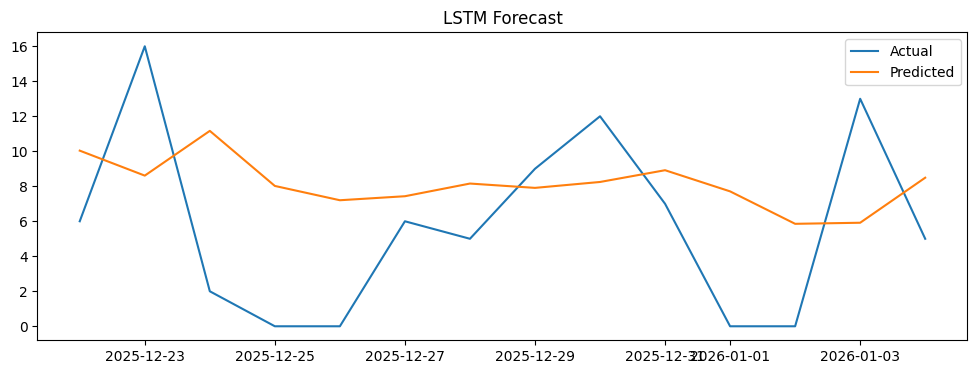

In [77]:
# aliniere date: X_test începe după lookback zile din test
test_index = df_lstm.index[target_idx[~train_mask]]
print("Test window", test_index.min(), "->", test_index.max(), "| points:", len(test_index))

plt.figure(figsize=(12,4))
plt.plot(test_index, y_true, label="Actual")
plt.plot(test_index, pred, label="Predicted")
plt.title(f"LSTM Forecast")
plt.legend()
plt.show()


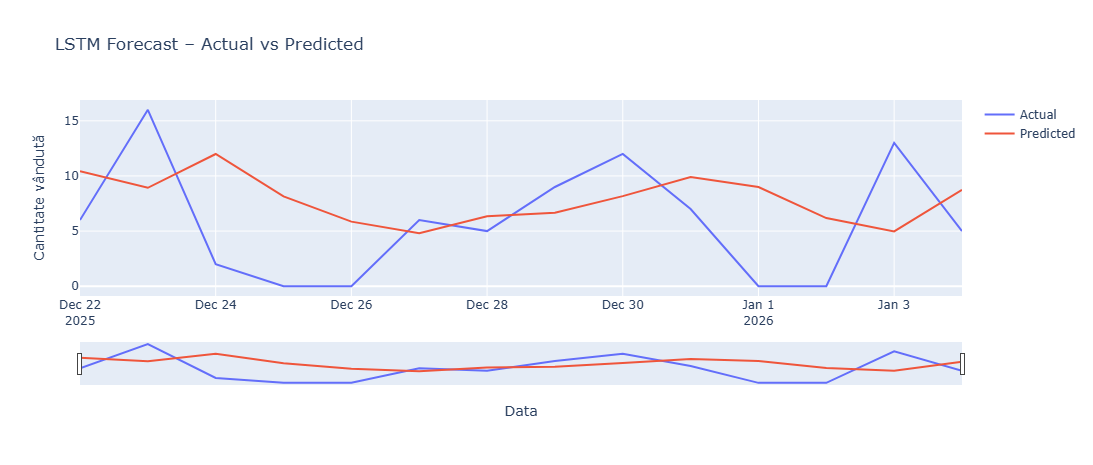

In [61]:
df_plot = pd.DataFrame({
    "DATA": test_index,
    "Actual": y_true,
    "Predicted": pred
})

df_long = df_plot.melt(
    id_vars="DATA",
    value_vars=["Actual", "Predicted"],
    var_name="Serie",
    value_name="Cantitate"
)

fig = px.line(
    df_long,
    x="DATA",
    y="Cantitate",
    color="Serie",
    title="LSTM Forecast – Actual vs Predicted",
    markers=False
)

fig.update_layout(
    xaxis_title="Data",
    yaxis_title="Cantitate vândută",
    hovermode="x unified",
    legend_title_text=""
)

fig.update_xaxes(rangeslider_visible=True)  # slider jos
fig.update_layout(width=1100, height=450)
fig.show()